In [7]:
import numpy as np
import pandas as pd
import scipy as sp
import topas2numpy as tn
import matplotlib.pyplot as plt
from ipywidgets import interact
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import seaborn as sns
import importlib

import sys
sys.path.append('..')
import topasAnalysisFunctions as taf
importlib.reload(taf)

<module 'topasAnalysisFunctions' from 'e:\\Christoph\\applications\\HEC_TOPAS\\testSim\\..\\topasAnalysisFunctions.py'>

In [35]:
path_dose = 'DoseGrid.csv'

data_dose = pd.read_csv(path_dose, names=['x', 'y', 'z', 'dose'], comment='#')

bin_x = 0.2
bin_y = 0.2
bin_z = 0.2


np.float64(24.5)

Text(0.5, 1.0, 'Dose vs Depth @ Beam Center')

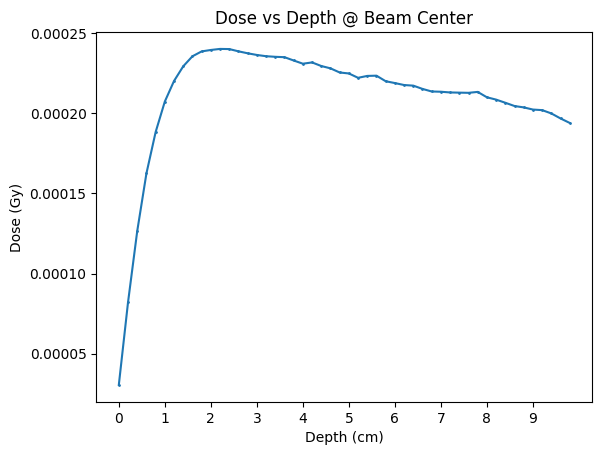

In [36]:
data_dose_filtered = data_dose[(data_dose['x'] == int(data_dose['x'].median())) & (data_dose['y'] == int(data_dose['y'].median()))]

# sns.lineplot(data=data_dose_filtered, x='z', y='dose')
plt.plot(data_dose_filtered['z'], data_dose_filtered['dose'], marker='o', linestyle='-', markersize=1)
plt.xlabel('Depth (cm)')
plt.ylabel('Dose (Gy)')
plt.xticks(ticks=np.arange(0, data_dose['z'].max(), step=5), labels=[f"{int(tick * bin_z)}" for tick in np.arange(0, data_dose['z'].max(), step=5)])
plt.title('Dose vs Depth @ Beam Center')

Text(0, 0.5, 'Dose (Gy)')

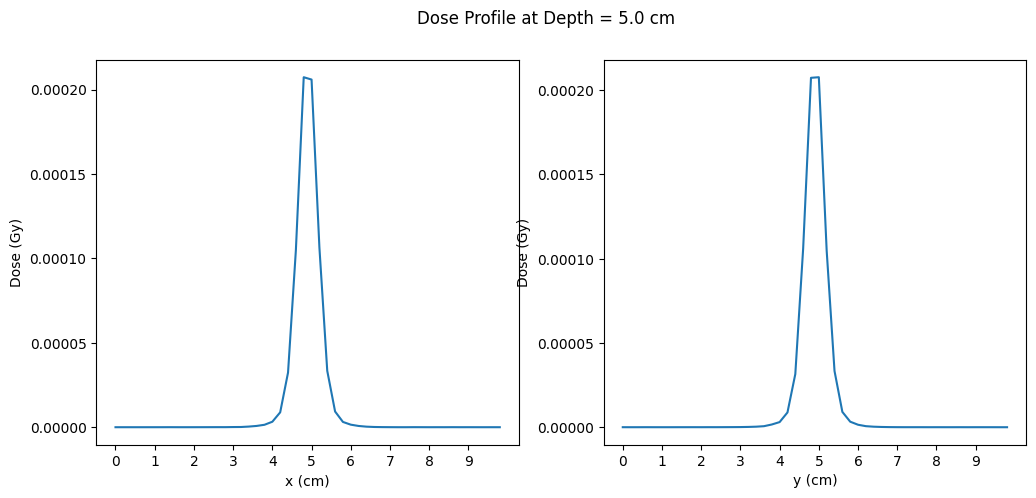

In [38]:
depth = 5.0  # example depth value
data_dose_filtered = data_dose[data_dose['z'] == depth]
data_dose_filtered_x = data_dose_filtered[(data_dose_filtered['y'] == int(data_dose_filtered['y'].median()))]
data_dose_filtered_y = data_dose_filtered[(data_dose_filtered['x'] == int(data_dose_filtered['x'].median()))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f'Dose Profile at Depth = {depth} cm')

sns.lineplot(data=data_dose_filtered_x, x='x', y='dose', ax=ax1)
ax1.set_xticks(np.arange(0, data_dose['x'].max(), step=5))
ax1.set_xticklabels([f"{int(tick * bin_x)}" for tick in np.arange(0, data_dose['x'].max(), step=5)])
ax1.set_xlabel('x (cm)')
ax1.set_ylabel('Dose (Gy)')

sns.lineplot(data=data_dose_filtered_y, x='y', y='dose', ax=ax2)
ax2.set_xticks(np.arange(0, data_dose['y'].max(), step=5))
ax2.set_xticklabels([f"{int(tick * bin_y)}" for tick in np.arange(0, data_dose['y'].max(), step=5)])
ax2.set_xlabel('y (cm)')
ax2.set_ylabel('Dose (Gy)')
